In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)

PROJECT_ROOT: c:\temp\python_learning\ml_projects\ml_projects_batch_01\05_bike_sharing_demand
DATA_RAW: c:\temp\python_learning\ml_projects\ml_projects_batch_01\05_bike_sharing_demand\data\raw


Ячейка 3 — load data

In [3]:
train = pd.read_csv(DATA_RAW / "train.csv")
test = pd.read_csv(DATA_RAW / "test.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (10886, 12)
test shape: (6493, 9)


Ячейка 4 — basic columns check

In [4]:
print("Train columns:")
print(train.columns.tolist())

print("\nOfficial test columns:")
print(test.columns.tolist())

Train columns:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

Official test columns:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']


Ячейка 5 — parse datetime

In [5]:
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])

print("train datetime dtype:", train["datetime"].dtype)
print("test datetime dtype:", test["datetime"].dtype)

train datetime dtype: datetime64[us]
test datetime dtype: datetime64[us]


Ячейка 6 — create datetime audit features

In [6]:
def add_datetime_audit_features(df):
    df = df.copy()
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.weekday
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
    return df


train_eda = add_datetime_audit_features(train)
test_eda = add_datetime_audit_features(test)

train_eda.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday,is_weekend
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,1


Ячейка 7 — initial validation of EDA frames

In [7]:
print("train_eda shape:", train_eda.shape)
print("test_eda shape:", test_eda.shape)

display(train_eda.head())
display(test_eda.head())

train_eda shape: (10886, 18)
test_eda shape: (6493, 15)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday,is_weekend
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,1


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,weekday,is_weekend
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3,0
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,3,0
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2,3,0
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3,0
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4,3,0


Ячейка 8 — leakage reminder

## Leakage notes

- `count` is the target and exists only in `train.csv`.
- Official `test.csv` does not contain `count`, so it must not be used for local validation.
- `casual` and `registered` are target components:
  `casual + registered == count`.
- Therefore, `casual` and `registered` must be excluded from feature matrix `X`.
- Random split is not the main validation scheme because the dataset has a time/day-of-month structure.

## Target analysis: count

In [8]:
target = "count"

train_eda[target].describe()

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

Нули и отрицательные значения

In [9]:
print("count min:", train_eda["count"].min())
print("count max:", train_eda["count"].max())
print("count == 0:", (train_eda["count"] == 0).sum())
print("count < 0:", (train_eda["count"] < 0).sum())

count min: 1
count max: 977
count == 0: 0
count < 0: 0


Skewness

In [10]:
count_skew = train_eda["count"].skew()
log_count_skew = np.log1p(train_eda["count"]).skew()

print("count skew:", count_skew)
print("log1p(count) skew:", log_count_skew)

count skew: 1.2420662117180776
log1p(count) skew: -0.8514116321738531


Distribution: count

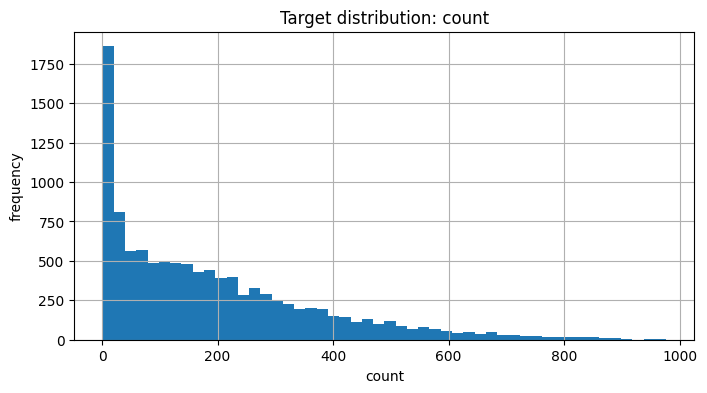

In [11]:
plt.figure(figsize=(8, 4))
train_eda["count"].hist(bins=50)
plt.title("Target distribution: count")
plt.xlabel("count")
plt.ylabel("frequency")
plt.show()

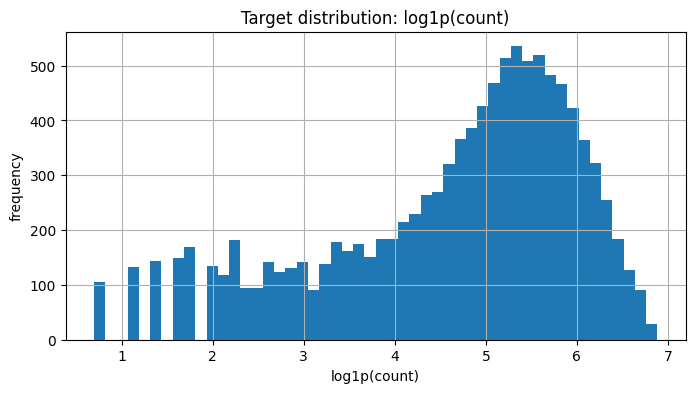

In [12]:
plt.figure(figsize=(8, 4))
np.log1p(train_eda["count"]).hist(bins=50)
plt.title("Target distribution: log1p(count)")
plt.xlabel("log1p(count)")
plt.ylabel("frequency")
plt.show()

In [13]:
train_eda["count"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])

0.00      1.00
0.01      2.00
0.05      5.00
0.25     42.00
0.50    145.00
0.75    284.00
0.95    563.75
0.99    774.15
1.00    977.00
Name: count, dtype: float64

### Target findings

- `count` is non-negative.
- There are no zero or negative target values in `train.csv`.
- The raw `count` distribution is right-skewed.
- `log1p(count)` gives a more compact target distribution.
- This supports trying a log-transformed target later, for example with `log1p(count)` or `TransformedTargetRegressor`.
- Since the Kaggle metric is RMSLE, predictions must be non-negative.

## Datetime structure analysis

In [14]:
print("Train datetime min:", train_eda["datetime"].min())
print("Train datetime max:", train_eda["datetime"].max())

print("\nOfficial test datetime min:", test_eda["datetime"].min())
print("Official test datetime max:", test_eda["datetime"].max())

Train datetime min: 2011-01-01 00:00:00
Train datetime max: 2012-12-19 23:00:00

Official test datetime min: 2011-01-20 00:00:00
Official test datetime max: 2012-12-31 23:00:00


In [15]:
print("Train years:")
display(train_eda["year"].value_counts().sort_index())

print("Official test years:")
display(test_eda["year"].value_counts().sort_index())

Train years:


year
2011    5422
2012    5464
Name: count, dtype: int64

Official test years:


year
2011    3223
2012    3270
Name: count, dtype: int64

In [16]:
print("Train months:")
display(train_eda["month"].value_counts().sort_index())

print("Official test months:")
display(test_eda["month"].value_counts().sort_index())

Train months:


month
1     884
2     901
3     901
4     909
5     912
6     912
7     912
8     912
9     909
10    911
11    911
12    912
Name: count, dtype: int64

Official test months:


month
1     545
2     440
3     572
4     528
5     576
6     528
7     576
8     563
9     528
10    540
11    526
12    571
Name: count, dtype: int64

In [17]:
print("Train days of month:")
display(train_eda["day"].value_counts().sort_index())

print("Official test days of month:")
display(test_eda["day"].value_counts().sort_index())

Train days of month:


day
1     575
2     573
3     573
4     574
5     575
6     572
7     574
8     574
9     575
10    572
11    568
12    573
13    574
14    574
15    574
16    574
17    575
18    563
19    574
Name: count, dtype: int64

Official test days of month:


day
20    574
21    574
22    569
23    573
24    573
25    572
26    567
27    552
28    563
29    526
30    514
31    336
Name: count, dtype: int64

In [18]:
print("Train hours:")
display(train_eda["hour"].value_counts().sort_index())

print("Official test hours:")
display(test_eda["hour"].value_counts().sort_index())

Train hours:


hour
0     455
1     454
2     448
3     433
4     442
5     452
6     455
7     455
8     455
9     455
10    455
11    455
12    456
13    456
14    456
15    456
16    456
17    456
18    456
19    456
20    456
21    456
22    456
23    456
Name: count, dtype: int64

Official test hours:


hour
0     271
1     270
2     267
3     264
4     255
5     265
6     270
7     272
8     272
9     272
10    272
11    272
12    272
13    273
14    273
15    273
16    274
17    274
18    272
19    272
20    272
21    272
22    272
23    272
Name: count, dtype: int64

In [19]:
print("Train weekdays:")
display(train_eda["weekday"].value_counts().sort_index())

print("Official test weekdays:")
display(test_eda["weekday"].value_counts().sort_index())

Train weekdays:


weekday
0    1551
1    1539
2    1551
3    1553
4    1529
5    1584
6    1579
Name: count, dtype: int64

Official test weekdays:


weekday
0    928
1    914
2    924
3    918
4    958
5    928
6    923
Name: count, dtype: int64

Visual check: day pattern

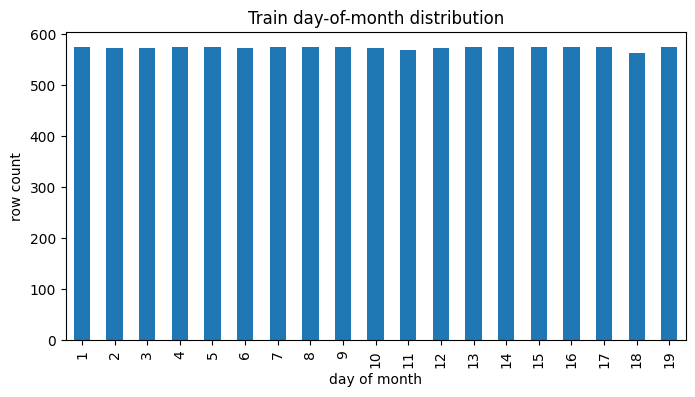

In [20]:
plt.figure(figsize=(8, 4))
train_eda["day"].value_counts().sort_index().plot(kind="bar")
plt.title("Train day-of-month distribution")
plt.xlabel("day of month")
plt.ylabel("row count")
plt.show()

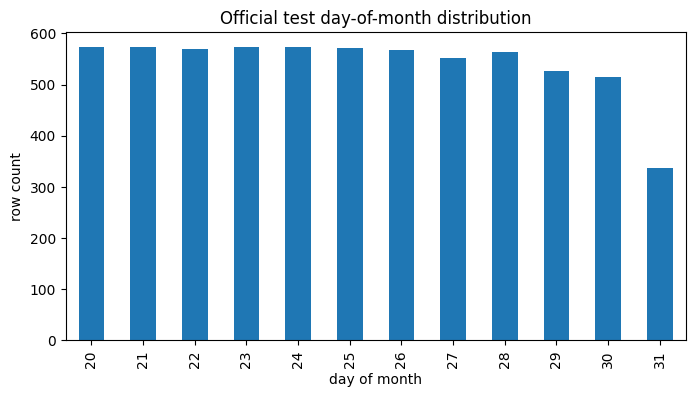

In [21]:
plt.figure(figsize=(8, 4))
test_eda["day"].value_counts().sort_index().plot(kind="bar")
plt.title("Official test day-of-month distribution")
plt.xlabel("day of month")
plt.ylabel("row count")
plt.show()

## Demand patterns

In [22]:
def demand_summary(df, group_col, target="count"):
    return (
        df.groupby(group_col)[target]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_index()
    )

Demand by hour

In [23]:
hour_summary = demand_summary(train_eda, "hour")
hour_summary

,count,mean,median,std,min,max
hour,,,,,,
0,455,55.138462,41.0,43.620012,2,283
1,454,33.859031,19.0,34.112105,1,168
2,448,22.899554,11.0,26.110267,1,119
3,433,11.757506,6.0,12.666442,1,66
4,442,6.407240,6.0,4.217633,1,28
5,452,19.767699,19.0,12.784293,1,57
6,455,76.259341,75.0,54.745333,1,213
7,455,213.116484,208.0,159.207044,1,596
8,455,362.769231,392.0,231.723065,8,839


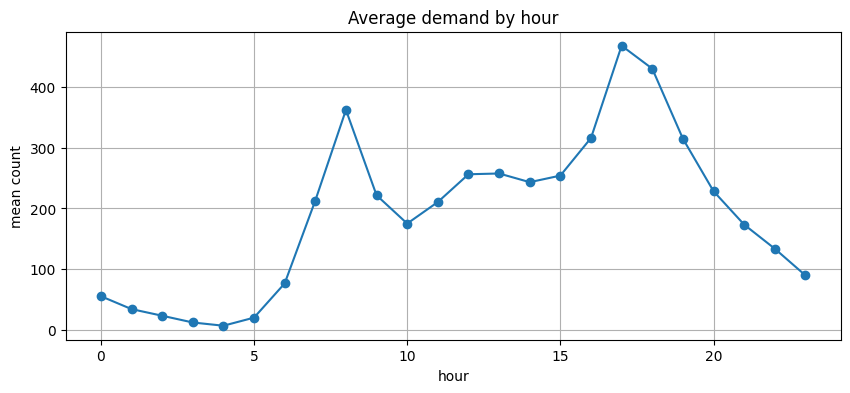

In [24]:
plt.figure(figsize=(10, 4))
hour_summary["mean"].plot(marker="o")
plt.title("Average demand by hour")
plt.xlabel("hour")
plt.ylabel("mean count")
plt.grid(True)
plt.show()

Demand by hour and workingday

Это очень важный график: он обычно показывает разные паттерны commute vs weekend.

In [25]:
hour_workingday = (
    train_eda
    .groupby(["hour", "workingday"])["count"]
    .mean()
    .unstack()
)

hour_workingday

workingday,0,1
hour,,
0,94.489655,36.732258
1,71.910345,16.003236
2,53.748252,8.436066
3,25.534722,4.892734
4,8.544828,5.363636
5,9.373239,24.529032
6,19.993103,102.577419
7,47.268966,290.690323
8,112.255172,479.945161


<Figure size 1000x400 with 0 Axes>

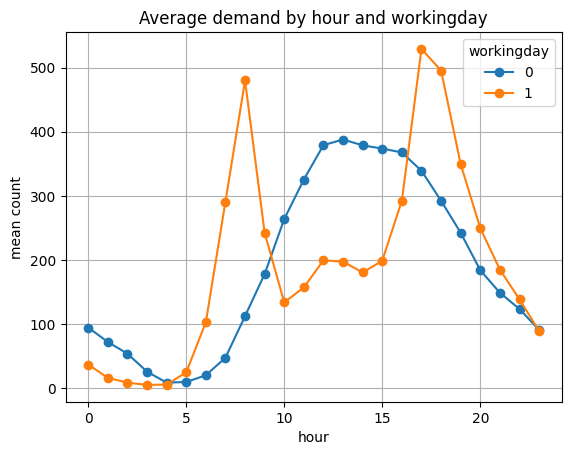

In [26]:
plt.figure(figsize=(10, 4))
hour_workingday.plot(marker="o")
plt.title("Average demand by hour and workingday")
plt.xlabel("hour")
plt.ylabel("mean count")
plt.grid(True)
plt.show()

Demand by workingday

In [27]:
workingday_summary = demand_summary(train_eda, "workingday")
workingday_summary

,count,mean,median,std,min,max
workingday,,,,,,
0,3474,188.506621,128.0,173.724015,1,783
1,7412,193.011873,151.0,184.513659,1,977


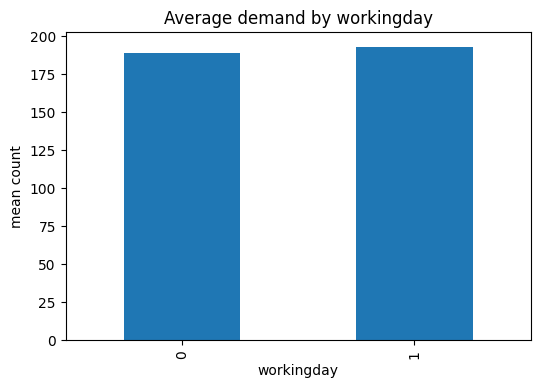

In [28]:
plt.figure(figsize=(6, 4))
workingday_summary["mean"].plot(kind="bar")
plt.title("Average demand by workingday")
plt.xlabel("workingday")
plt.ylabel("mean count")
plt.show()

Demand by holiday

In [29]:
holiday_summary = demand_summary(train_eda, "holiday")
holiday_summary

,count,mean,median,std,min,max
holiday,,,,,,
0,10575,191.741655,145.0,181.513131,1,977
1,311,185.877814,133.0,168.300531,1,712


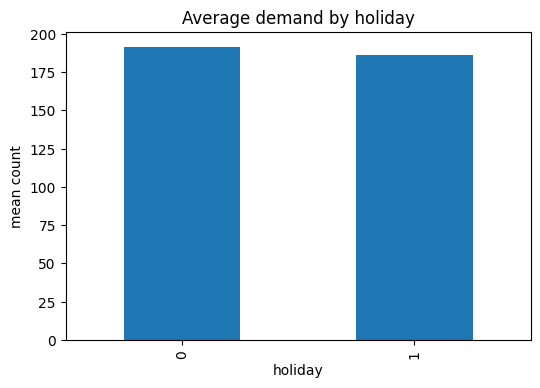

In [30]:
plt.figure(figsize=(6, 4))
holiday_summary["mean"].plot(kind="bar")
plt.title("Average demand by holiday")
plt.xlabel("holiday")
plt.ylabel("mean count")
plt.show()

Demand by month

In [31]:
month_summary = demand_summary(train_eda, "month")
month_summary

,count,mean,median,std,min,max
month,,,,,,
1,884,90.366516,65.0,95.302518,1,512
2,901,110.003330,78.0,109.802322,1,539
3,901,148.169811,100.0,155.352814,1,801
4,909,184.160616,133.0,182.417619,1,822
5,912,219.459430,182.0,189.320173,1,873
6,912,242.031798,206.0,199.628690,1,869
7,912,235.325658,209.5,184.857337,1,872
8,912,234.118421,193.0,197.198461,1,897
9,909,233.805281,188.0,208.915910,1,977


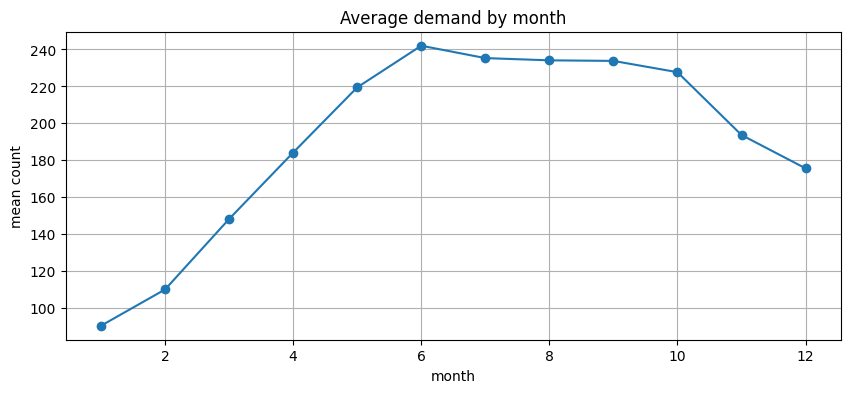

In [32]:
plt.figure(figsize=(10, 4))
month_summary["mean"].plot(marker="o")
plt.title("Average demand by month")
plt.xlabel("month")
plt.ylabel("mean count")
plt.grid(True)
plt.show()

Demand by season

In [33]:
season_summary = demand_summary(train_eda, "season")
season_summary

,count,mean,median,std,min,max
season,,,,,,
1,2686,116.343261,78.0,125.273974,1,801
2,2733,215.251372,172.0,192.007843,1,873
3,2733,234.417124,195.0,197.151001,1,977
4,2734,198.988296,161.0,177.622409,1,948


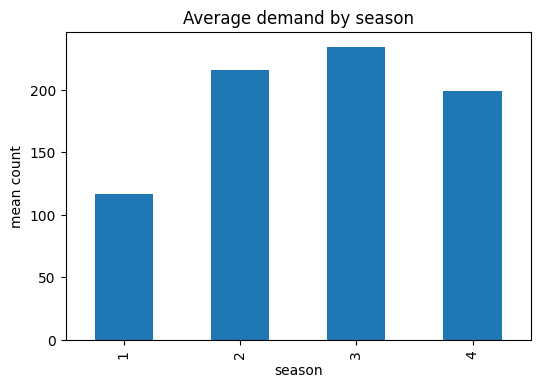

In [34]:
plt.figure(figsize=(6, 4))
season_summary["mean"].plot(kind="bar")
plt.title("Average demand by season")
plt.xlabel("season")
plt.ylabel("mean count")
plt.show()

Demand by weather

In [35]:
weather_summary = demand_summary(train_eda, "weather")
weather_summary

,count,mean,median,std,min,max
weather,,,,,,
1,7192,205.236791,161.0,187.959566,1,977
2,2834,178.955540,134.0,168.366413,1,890
3,859,118.846333,71.0,138.581297,1,891
4,1,164.000000,164.0,NaN,164,164


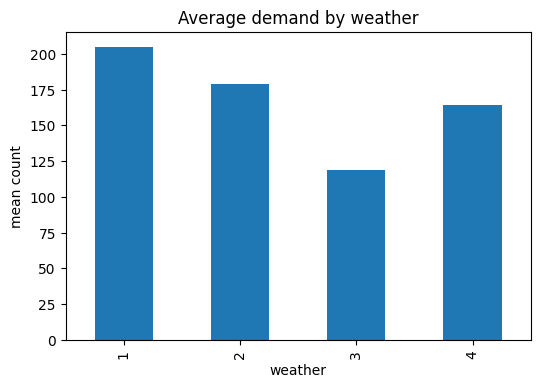

In [36]:
plt.figure(figsize=(6, 4))
weather_summary["mean"].plot(kind="bar")
plt.title("Average demand by weather")
plt.xlabel("weather")
plt.ylabel("mean count")
plt.show()

### Demand pattern findings

- Demand has a strong hourly pattern.
- Hour is likely one of the most important datetime-derived features.
- Working days and non-working days may have different hourly profiles.
- Month and season show seasonal demand differences.
- Weather categories show demand differences, but category frequencies should be considered.
- These findings support using datetime-derived features and treating `season`, `weather`, `workingday`, and `holiday` carefully as categorical/calendar features later.

## Weather and numeric feature analysis

In [37]:
weather_numeric_cols = ["temp", "atemp", "humidity", "windspeed"]

train_eda[weather_numeric_cols].describe()

,temp,atemp,humidity,windspeed
count,10886.00000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395
std,7.79159,8.474601,19.245033,8.164537
min,0.82000,0.760000,0.000000,0.000000
25%,13.94000,16.665000,47.000000,7.001500
50%,20.50000,24.240000,62.000000,12.998000
75%,26.24000,31.060000,77.000000,16.997900
max,41.00000,45.455000,100.000000,56.996900


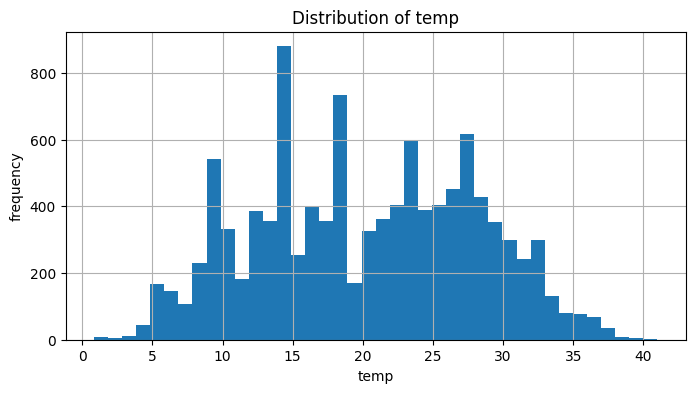

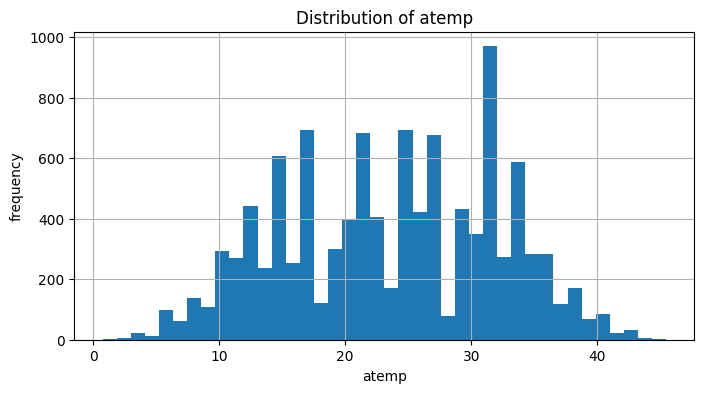

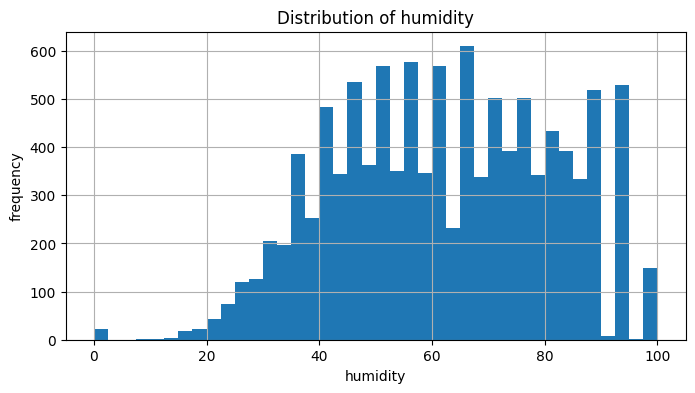

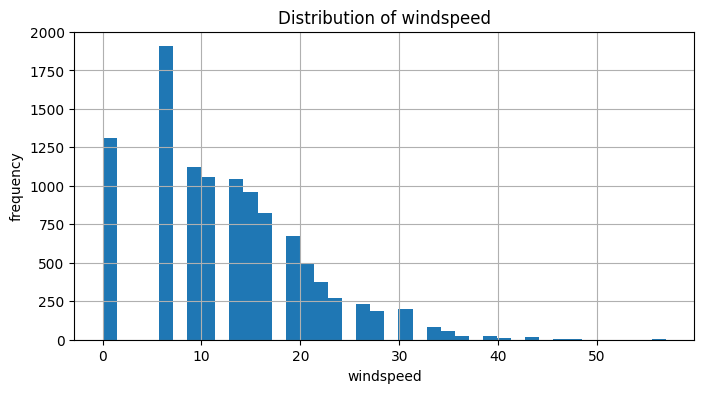

In [38]:
for col in weather_numeric_cols:
    plt.figure(figsize=(8, 4))
    train_eda[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

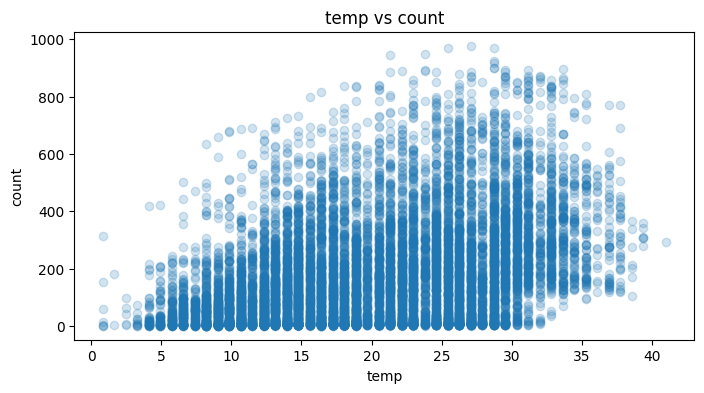

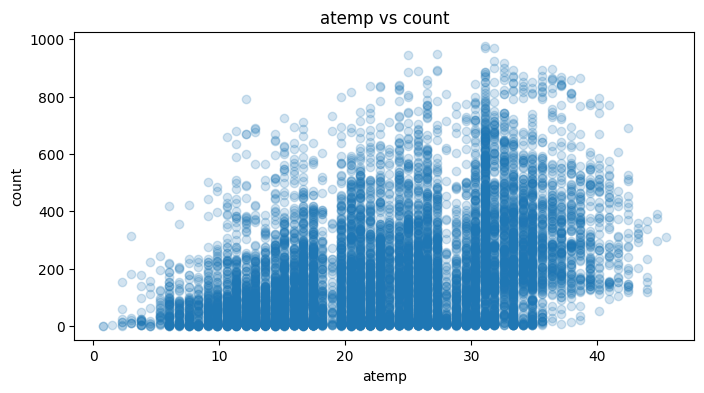

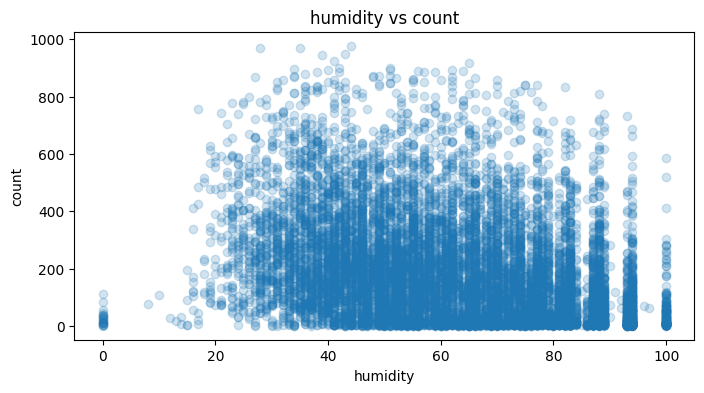

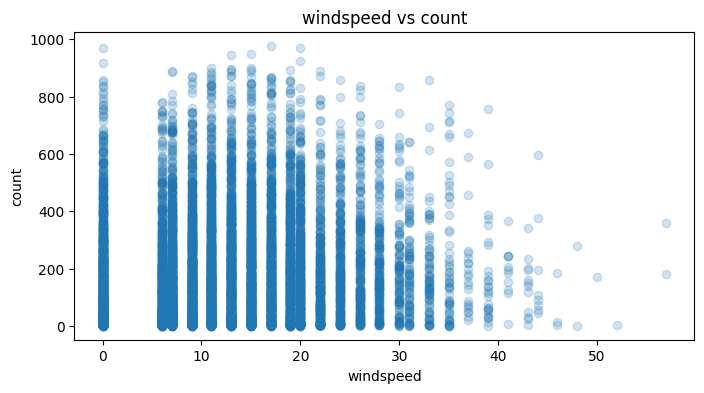

In [39]:
for col in weather_numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.scatter(train_eda[col], train_eda["count"], alpha=0.2)
    plt.title(f"{col} vs count")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

Correlation among weather features and count

In [40]:
weather_corr_cols = weather_numeric_cols + ["count"]

train_eda[weather_corr_cols].corr()

,temp,atemp,humidity,windspeed,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.101369
count,0.394454,0.389784,-0.317371,0.101369,1.000000


Correlation with count only

In [41]:
train_eda[weather_corr_cols].corr()["count"].sort_values(ascending=False)

count        1.000000
temp         0.394454
atemp        0.389784
windspeed    0.101369
humidity    -0.317371
Name: count, dtype: float64

Check zero windspeed

In [42]:
print("windspeed == 0:", (train_eda["windspeed"] == 0).sum())
print("windspeed == 0 share:", (train_eda["windspeed"] == 0).mean())

windspeed == 0: 1313
windspeed == 0 share: 0.12061363218813155


Check temp and atemp relation

In [43]:
print("Correlation temp vs atemp:", train_eda["temp"].corr(train_eda["atemp"]))

Correlation temp vs atemp: 0.9849481104817077


### Weather/numeric feature findings

- `temp` and `atemp` are strongly related and may contain overlapping information.
- Higher temperature is generally associated with higher demand, but the relationship is not purely linear.
- Higher humidity is generally associated with lower demand.
- `windspeed` has weaker direct relationship with demand.
- `windspeed == 0` appears in the data and should be treated carefully as a possible measurement/default value issue.
- No scaler/imputer is fitted at EDA stage.

## Correlation audit and leakage-aware feature planning

Full numeric correlation with count

In [44]:
numeric_cols = train_eda.select_dtypes(include="number").columns.tolist()

corr_with_count = (
    train_eda[numeric_cols]
    .corr(numeric_only=True)["count"]
    .sort_values(ascending=False)
)

corr_with_count

count         1.000000
registered    0.970948
casual        0.690414
hour          0.400601
temp          0.394454
atemp         0.389784
year          0.260403
month         0.166862
season        0.163439
windspeed     0.101369
day           0.019826
workingday    0.011594
weekday      -0.002283
holiday      -0.005393
is_weekend   -0.009925
weather      -0.128655
humidity     -0.317371
Name: count, dtype: float64

Valid feature correlation only

In [45]:
leakage_cols = ["casual", "registered"]
target_col = "count"

valid_numeric_cols = [
    col for col in numeric_cols
    if col not in leakage_cols + [target_col]
]

valid_corr_with_count = (
    train_eda[valid_numeric_cols + [target_col]]
    .corr(numeric_only=True)[target_col]
    .sort_values(ascending=False)
)

valid_corr_with_count

count         1.000000
hour          0.400601
temp          0.394454
atemp         0.389784
year          0.260403
month         0.166862
season        0.163439
windspeed     0.101369
day           0.019826
workingday    0.011594
weekday      -0.002283
holiday      -0.005393
is_weekend   -0.009925
weather      -0.128655
humidity     -0.317371
Name: count, dtype: float64

Feature groups draft

In [46]:
target_col = "count"

leakage_cols = ["casual", "registered"]

datetime_feature_candidates = [
    "year",
    "month",
    "day",
    "hour",
    "weekday",
    "is_weekend",
]

calendar_categorical_candidates = [
    "season",
    "holiday",
    "workingday",
    "weather",
]

weather_numeric_candidates = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
]

feature_candidates = (
    datetime_feature_candidates
    + calendar_categorical_candidates
    + weather_numeric_candidates
)

print("Target:", target_col)
print("Leakage columns:", leakage_cols)
print("Feature candidates:")
print(feature_candidates)

print("\nColumns excluded from X:")
print(leakage_cols + [target_col, "datetime"])

Target: count
Leakage columns: ['casual', 'registered']
Feature candidates:
['year', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']

Columns excluded from X:
['casual', 'registered', 'count', 'datetime']


In [47]:
set(feature_candidates).intersection(leakage_cols)

set()

### Correlation and feature planning findings

- `casual` and `registered` have very high correlation with `count`, but they are target components and must be excluded from `X`.
- Valid high-signal candidates include `hour`, `temp`, `atemp`, `humidity`, `year`, `month`, `season`, and weather/calendar features.
- Correlation is only a linear diagnostic and does not capture interactions such as `hour × workingday`.
- `datetime` itself should not be passed directly to most sklearn models, but datetime-derived features can be used.
- Final preprocessing will be implemented later inside a reproducible workflow/Pipeline.

## Validation, leakage control, and feature engineering hypotheses

### Local validation scheme

The official Kaggle test set is not suitable for local validation because it does not contain the target `count`.

The dataset has a clear day-of-month split:

- train.csv: days 1–19 of each month
- official test.csv: days 20–31 of each month

Therefore, random split is not appropriate as the main validation scheme.

First local validation scheme:

- local train: days 1–15 of each month from `train.csv`
- local validation: days 16–19 of each month from `train.csv`

This approximates the official structure better than random split because validation uses later days within each month.

Limitations:

- local validation still uses days 16–19, while official test uses days 20–31;
- it may still be somewhat easier than the real Kaggle test;
- later stages may consider additional time-aware validation variants.

### Leakage control

Columns excluded from feature matrix `X`:

- `count`: target
- `casual`: target component
- `registered`: target component
- `datetime`: raw datetime column, not directly passed to standard sklearn models

`casual + registered == count`, so using either `casual` or `registered` would leak target information.

### Feature candidates

Datetime-derived candidates:

- `year`
- `month`
- `hour`
- `weekday`
- `is_weekend`

Potentially controversial:

- `day`

`day` is available from `datetime`, so it is not target leakage. However, it may not generalize well because train contains days 1–19, while official test contains days 20–31. It can encode the competition split structure rather than a stable demand pattern.

Calendar/weather categorical candidates:

- `season`
- `holiday`
- `workingday`
- `weather`

Weather/numeric candidates:

- `temp`
- `atemp`
- `humidity`
- `windspeed`

### Feature engineering hypotheses for later stages

Likely useful:

- `hour`, because demand has strong hourly patterns;
- `month` / `season`, because demand has seasonal patterns;
- `year`, because 2012 demand appears different from 2011;
- `temp` / `atemp`, because demand increases with warmer weather;
- `humidity`, because it is negatively associated with demand;
- `weather`, because worse weather is associated with lower demand;
- `workingday`, especially through interaction with `hour`.

Possible later additions:

- cyclic encoding for `hour`, `month`, `weekday`;
- interaction-like features such as `hour × workingday`;
- using models that naturally learn interactions.

### Target transformation hypothesis

The target `count` is right-skewed.

Later modeling should compare:

- raw target regression;
- `log1p(count)` target;
- `TransformedTargetRegressor` with `log1p` / `expm1`.

Because the primary metric is RMSLE, log-target modeling is a strong candidate.

### Preprocessing notes

At EDA stage:

- no model is trained;
- no scaler is fitted;
- no encoder is fitted;
- no imputer is fitted;
- official test.csv is not used for validation.

In later stages, preprocessing that learns parameters from data must be fitted only on local train data or inside Pipeline/CV.